In [ ]:
import polars as pl
from datasets import load_dataset

# 1. Load the dataset using the official Hugging Face loader
# This handles the URL encoding and slash issues automatically
dataset = load_dataset("Jinyan1/COLING_2025_MGT_en", split="train")

# 2. Convert to Polars (Zero-copy)
# In 2026, .to_polars() is the fastest bridge
df = dataset.to_polars()

# 3. Quick Data Audit
print(f"Total Rows: {len(df)}")
print(df.head())

Total Rows: 610767
shape: (5, 7)
┌────────────────────────┬────────┬────────────┬──────┬───────────┬───────┬────────────────────────┐
│ id                     ┆ source ┆ sub_source ┆ lang ┆ model     ┆ label ┆ text                   │
│ ---                    ┆ ---    ┆ ---        ┆ ---  ┆ ---       ┆ ---   ┆ ---                    │
│ str                    ┆ str    ┆ str        ┆ str  ┆ str       ┆ i64   ┆ str                    │
╞════════════════════════╪════════╪════════════╪══════╪═══════════╪═══════╪════════════════════════╡
│ f05034ca-d1da-445d-a6a ┆ m4gt   ┆ reddit     ┆ en   ┆ llama3-8b ┆ 1     ┆ Hitler's plans for the │
│ 2-5869ad…              ┆        ┆            ┆      ┆           ┆       ┆ success…               │
│ e7d7fe23-3709-4e14-aa2 ┆ mage   ┆ squad      ┆ en   ┆ human     ┆ 0     ┆ The Bush               │
│ d-d76821…              ┆        ┆            ┆      ┆           ┆       ┆ administration then t… │
│ 1a68d42e-4202-4e36-bce ┆ mage   ┆ yelp       ┆ en   ┆ hu

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your existing DataFrame with columns: text, label, model, lang
# =============================================================================
# 1. CLEAN & PREPROCESS
# =============================================================================

df_processed = (
    df.lazy()
    .drop_nulls(subset=["text", "label", "model"])

    # 🧹 MARKDOWN CLEANING STEP
    .with_columns(
        pl.col("text")
          # Remove code blocks (```)
          .str.replace_all(r"```[\s\S]*?```", " ")
          # Remove inline code (`)
          .str.replace_all(r"`", "")
          # Remove images: ![alt](url)
          .str.replace_all(r"!\[[^\]]*\]\([^\)]*\)", "")
          # Remove links: [text](url)
          .str.replace_all(r"\[[^\]]*\]\([^\)]*\)", "")
          # Remove bold/italic/strikethrough markers (**, *, ~~)
          .str.replace_all(r"[\*\~]", "")
          # Remove headers (# ## ###)
          .str.replace_all(r"(?m)^#{1,6}\s+", "")
          # Remove list markers (- item, * item, + item, 1. item)
          .str.replace_all(r"(?m)^\s*[-*+]\s+", "")
          .str.replace_all(r"(?m)^\s*\d+\.\s+", "")
          # Normalize whitespace & trim
          .str.replace_all(r"\s+", " ")
          .str.strip_chars()
          .alias("text_clean")
    )

    # 📏 WORD COUNT CALCULATION
    .with_columns(
        pl.col("text_clean").str.split(" ").list.len().alias("word_count")
    )
    .collect()
    .to_pandas()
)

print(f"✅ Cleaned & processed: {len(df_processed):,} samples")

✅ Cleaned & processed: 610,767 samples


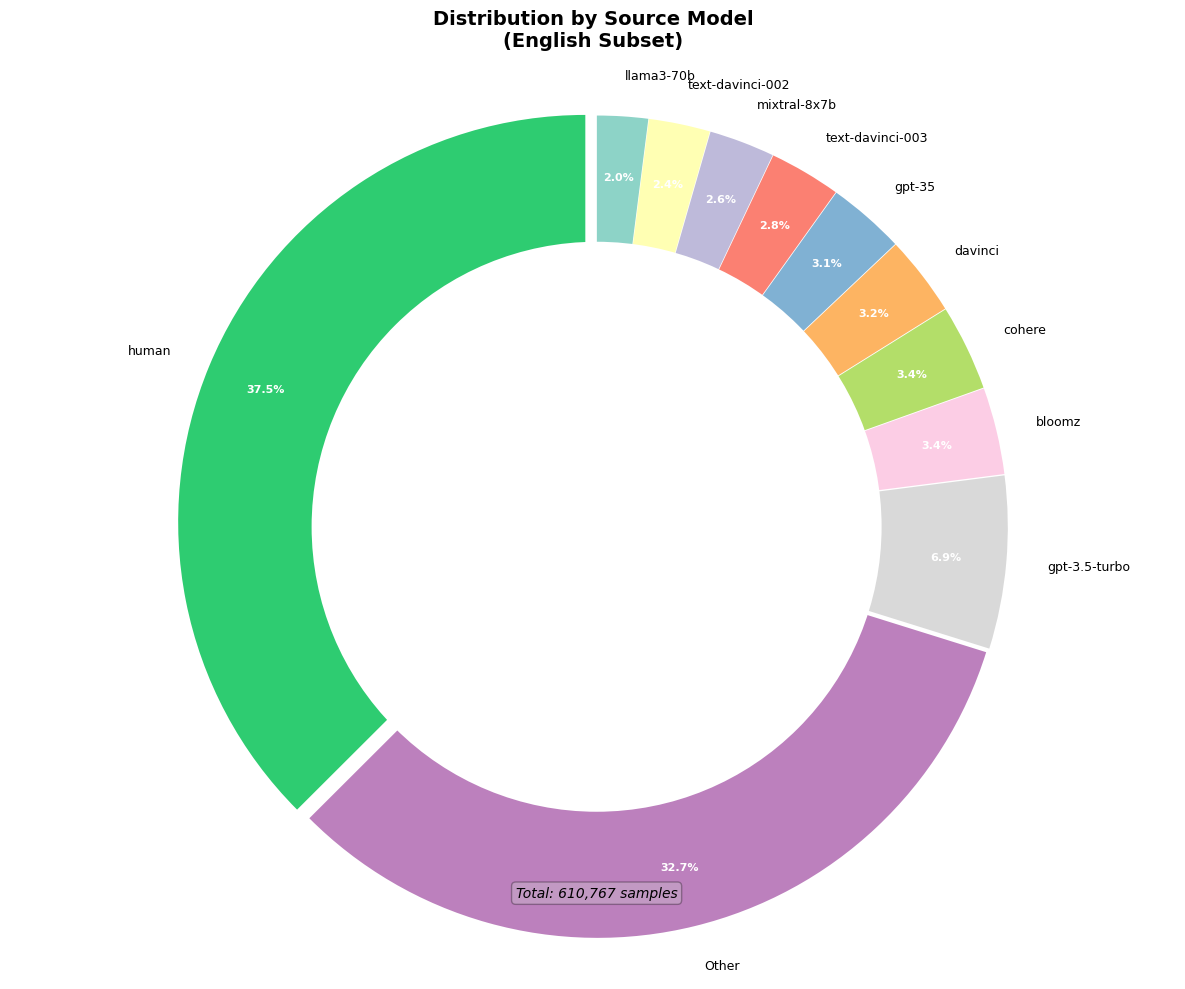


🥧 Model Distribution Summary:
   llama3-70b               :  12,333 (  2.0%)
   text-davinci-002         :  14,884 (  2.4%)
   mixtral-8x7b             :  15,865 (  2.6%)
   text-davinci-003         :  17,332 (  2.8%)
   gpt-35                   :  18,671 (  3.1%)
   davinci                  :  19,345 (  3.2%)
   cohere                   :  20,808 (  3.4%)
   bloomz                   :  21,061 (  3.4%)
   gpt-3.5-turbo            :  41,847 (  6.9%)
   Other                    : 199,699 ( 32.7%)
   human                    : 228,922 ( 37.5%)


In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import pandas as pd

# =============================================================================
# ASSUMPTION: You have 'df' with columns: model, count (or text, label, etc.)
# We will recalculate counts to be safe.
# =============================================================================

# 1. Count by Model (if not already calculated)
# If you already have 'model_counts' calculated, skip this step.
model_counts = (
    df.lazy()
    .group_by("model")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
    .to_pandas()
)

# 2. Prepare for Pie Chart: Group small models into "Other"
TOP_N = 10  # Show top 10 models

if len(model_counts) > TOP_N:
    # Keep top N, sum the rest
    top_models = model_counts.iloc[:TOP_N].copy()
    other_count = model_counts.iloc[TOP_N:]["count"].sum()

    # Add "Other" row
    other_row = pd.DataFrame({"model": ["Other"], "count": [int(other_count)]})
    plot_df = pd.concat([top_models, other_row], ignore_index=True)
else:
    plot_df = model_counts.copy()

# Sort ascending for pie chart (starts at top, goes clockwise)
plot_df = plot_df.sort_values("count", ascending=True).reset_index(drop=True)

# =============================================================================
# 3. CREATE PIE CHART (Fixed Colors)
# =============================================================================

plt.figure(figsize=(12, 10))

# ✅ FIX: Convert colormap output to a list so we can assign hex strings later
colors = list(plt.cm.Set3(range(len(plot_df))))

# Highlight "human" if present
if "human" in plot_df["model"].values:
    human_idx = plot_df[plot_df["model"] == "human"].index[0]
    colors[human_idx] = "#2ecc71"  # Now this works!

# Create pie chart
wedges, texts, autotexts = plt.pie(
    plot_df["count"],
    labels=plot_df["model"],
    autopct=lambda pct: f'{pct:.1f}%',
    colors=colors,
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 9},
    pctdistance=0.85,
    explode=[0.03 if m == "human" else 0.01 for m in plot_df["model"]]
)

# Style percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

# Donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Title & annotation
plt.title("Distribution by Source Model\n(English Subset)", fontsize=14, fontweight="bold", pad=20)
total = plot_df["count"].sum()
plt.annotate(f"Total: {total:,} samples",
             xy=(0, 0), xytext=(0, -0.9),
             ha='center', va='center', fontsize=10, style='italic',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.3))

plt.axis('equal')
plt.tight_layout()
plt.show()

# 4. Print Summary
print(f"\n🥧 Model Distribution Summary:")
for _, row in plot_df.iterrows():
    pct = row["count"] / total * 100
    print(f"   {row['model']:25s}: {row['count']:7,} ({pct:5.1f}%)")

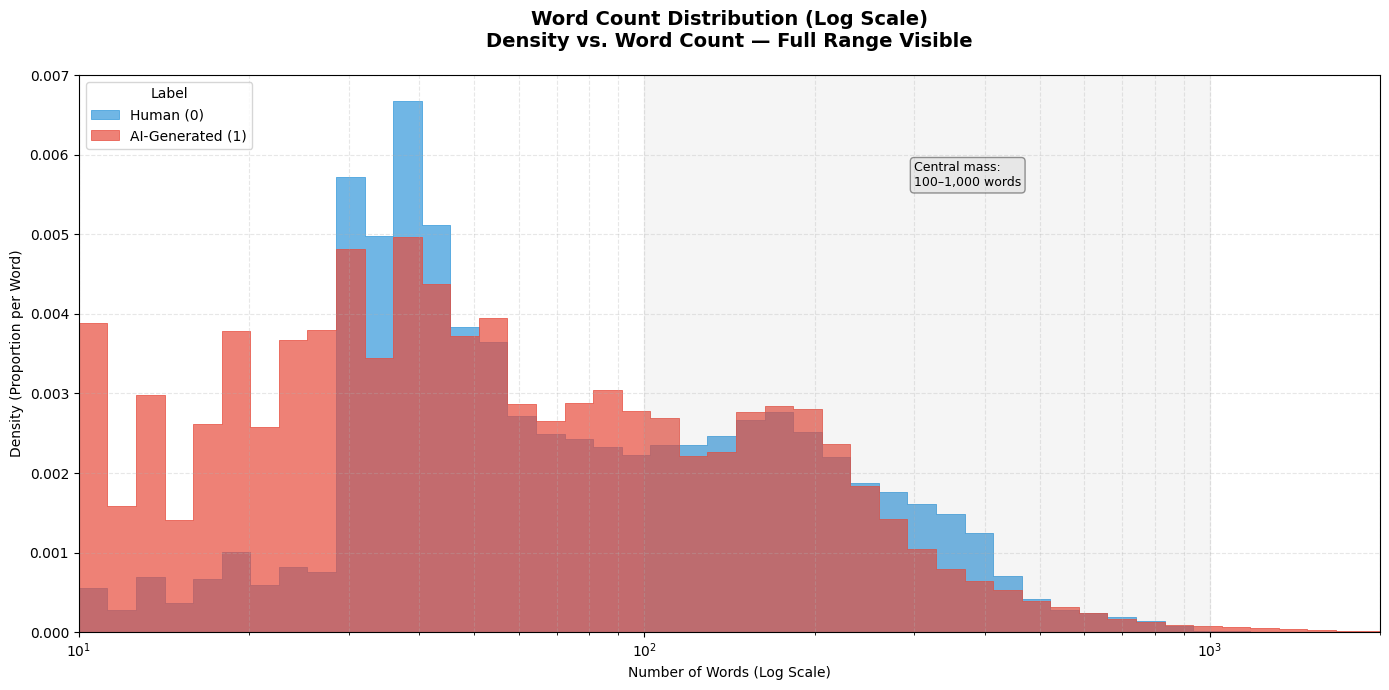

In [ ]:
import numpy as np

plt.figure(figsize=(14, 7))

# Create log-spaced bins for fair comparison across scales
bins = np.logspace(np.log10(10), np.log10(df_processed["word_count"].max()), 50)

sns.histplot(
    data=df_processed,
    x="word_count",
    hue="label",
    element="step",
    stat="density",           # Normalize for bin width → fair comparison
    common_norm=False,
    palette={0: "#e74c3c", 1: "#3498db"},
    alpha=0.7,
    bins=bins,
    linewidth=0.5
)

# Log scale + safe limits (can't use 0 on log axis)
plt.xscale("log")
plt.xlim(10, 2000)

# Annotate central mass region (where most data lives)
plt.axvspan(100, 1000, color="gray", alpha=0.08, label="Central mass: ~71% of data")
plt.annotate("Central mass:\n100–1,000 words",
             xy=(300, plt.ylim()[1]*0.8),
             fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.4))

# Annotate mode
mode_val = df_processed["word_count"].mode()[0]

plt.title("Word Count Distribution (Log Scale)\nDensity vs. Word Count — Full Range Visible",
          fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Number of Words (Log Scale)")
plt.ylabel("Density (Proportion per Word)")
plt.legend(title="Label", labels=["Human (0)", "AI-Generated (1)"])
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

<BarContainer object of 2 artists>

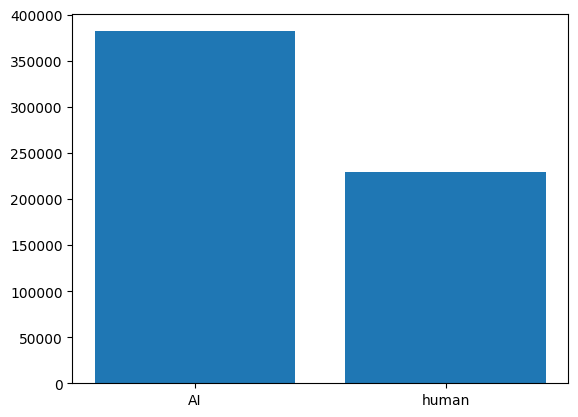

In [ ]:
ai_count = df.filter(pl.col("label") == 1).shape[0]
human_count = df.filter(pl.col("label") == 0).shape[0]
plt.bar(x=["AI","human"],height=[ai_count,human_count])

In [ ]:
import polars as pl
import pandas as pd
# 1. Load the dataset using the official Hugging Face loader
# This handles the URL encoding and slash issues automatically
dataset = load_dataset("Jinyan1/COLING_2025_MGT_multingual", split="train")

# 2. Convert to Polars (Zero-copy)
# In 2026, .to_polars() is the fastest bridge
df = dataset.to_polars()

# 3. Quick Data Audit
print(f"Total Rows: {len(df)}")
print(df.head())


README.md:   0%|          | 0.00/589 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/213M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/213M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/212M [00:00<?, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/275M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/674083 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/288894 [00:00<?, ? examples/s]

Total Rows: 674083
shape: (5, 7)
┌───────────────────────┬────────┬─────────────┬──────┬─────────────┬───────┬──────────────────────┐
│ id                    ┆ source ┆ sub_source  ┆ lang ┆ model       ┆ label ┆ text                 │
│ ---                   ┆ ---    ┆ ---         ┆ ---  ┆ ---         ┆ ---   ┆ ---                  │
│ str                   ┆ str    ┆ str         ┆ str  ┆ str         ┆ i64   ┆ str                  │
╞═══════════════════════╪════════╪═════════════╪══════╪═════════════╪═══════╪══════════════════════╡
│ 808a846d-41c1-46ff-80 ┆ m4gt   ┆ arxiv       ┆ en   ┆ gemma-7b-it ┆ 1     ┆ This report          │
│ ab-892b01…            ┆        ┆             ┆      ┆             ┆       ┆ summarizes the fin…  │
│ 673ec6fc-624a-4ad5-8d ┆ mage   ┆ wp          ┆ en   ┆ human       ┆ 0     ┆ I've been standing   │
│ 5f-a5950b…            ┆        ┆             ┆      ┆             ┆       ┆ here for da…         │
│ 3059e6e4-1724-4745-a8 ┆ mage   ┆ xsum        ┆ en   ┆ fl

In [ ]:
df = df.filter(pl.col("lang") != "en")

<BarContainer object of 8 artists>

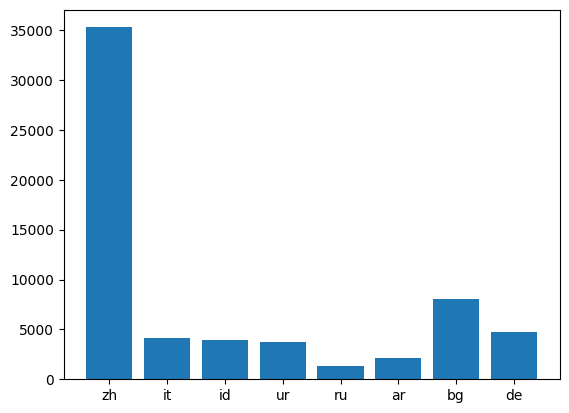

In [ ]:
df_counts = df["lang"].value_counts()
plt.bar(df_counts['lang'],df_counts['count'])

In [ ]:
df_counts

lang,count
str,u32
"""zh""",35284
"""it""",4174
"""id""",3976
"""ur""",3761
"""ru""",1314
"""ar""",2114
"""bg""",8091
"""de""",4693
